In [59]:
NZ=2396; NX=13601; H=1.25

velmin=1065
velmax=4700

#chosen
fpeak=6

#consequently
h=int(velmin/fpeak/2.5/5)
nz=int(NZ*H/h)+1
nx=int(NX*H/h)+1
print(h,nz,nx)

dt=0.6*h/velmax *0.98
T=5 #time window [s]
nt=int(T/dt)
print(dt,nt)

dt=0.00175
nt=int(T/dt)
print(dt,nt)

ntr=600

14 214 1215
0.0017514893617021278 2854
0.00175 2857


In [60]:
import os
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def write(filename,data,n=(nx,nz)):
    data.T.astype('float32').tofile(filename)

    
def hilb(data,axis=0):
    return np.imag(hilbert(data,axis=axis))

    
def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)
    
def run(app='../../exe/FWD',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

## Prepare

In [4]:
##code
#!(cd ../../ ; git pull ; git checkout teaching ; make prepare)
#!(cd ../../FWD ; make cleanall ; make)
#!(cd ../../FWI ; make cleanall ; make)
#!gfortran smoothgauss2dfast_zhou.f90 -o smoothgauss2dfast_zhou

In [10]:
# #clone model
# # !wget https://s3.amazonaws.com/open.source.geoscience/open_data/elastic-marmousi/elastic-marmousi-model.tar.gz #https://wiki.seg.org/wiki/AGL_Elastic_Marmousi
# # !tar -xvzf elastic-marmousi-model.tar.gz
# # !(cd ./elastic-marmousi-model/model/ ; for fi in `ls *.tar.gz`; do tar -xvzf $$fi; done)
# !segyread tape=./elastic-marmousi-model/model/MODEL_P-WAVE_VELOCITY_1.25m.segy | sugain bias=0 | sustrip > vp.bin
# !segyread tape=./elastic-marmousi-model/model/MODEL_DENSITY_1.25m.segy | sustrip | farith op=scale scale=1000 > rho.bin  #convert to [kg/m3]

# !unif2 ninf=1 nz=281 nx=1361 v00=2000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=4000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=1 > rho.bin

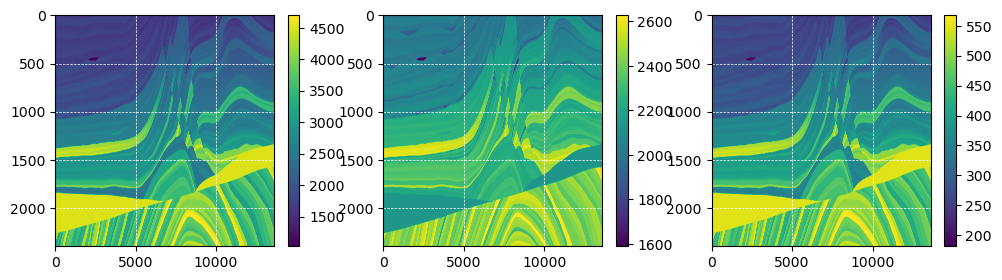

In [37]:
#chop the water layer
vp = read('vp.bin',(13601,2801)) [405:,:]
rho= read('rho.bin',(13601,2801))[405:,:]

#make Qp model by empirical law
qp = vp**0.5 #leads to a range of ~35--65, small enough to cause instability
qp = vp**0.75 #leads to a range of ~200--550, not yet instability

#plot
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(vp)
plt.subplot(1,3,2); imshow(rho)
plt.subplot(1,3,3); imshow(qp)

In [17]:
print(vp.shape)

(2396, 13601)


In [38]:
#save to disk
write('vpt.bin',vp)
write('rhot.bin',rho)
write('qpt.bin',qp)

In [61]:
#downsample true models
!make -B true

#make init models
!make -B init

#catenate
!cat vpt.14m   rhot.14m   qpt.14m  > true
!cat vpt.init  rhot.init  qpt.init > init

echo 13.4453
13.4453
./smoothgauss2dfast_zhou < par
 Input / Output file names (name_in name_out)
 Grid dimensions (n1 n2)
 Grid interval (d1 d2)
 Standard deviation of the Gaussian function (sig1, sig2)
 Wavenumbers (without factor 2*pi) higher than 0.48/sig will be suppressed
 c'est à dire que les nombres d'onde qui sont plus large que 0.48/sig ont l'amplitude sous 1% du crête. 
 Smooth parameter (0) or its inverse (1) or its inverse square (2)
 Constant topography (>=0) or variant (<0)
  go to the square inverse
  grids points involved il2 il1 =           44          44
  go back from the square inverse
   9.30400666E+10
unisam2 < vpt.smth > vpt.14m \
  nx1=2396  dx1=1.25    nx2=13601  dx2=1.25 \
  n1=214    d1=14      n2=1215   d2=14
echo 13.4453
13.4453
./smoothgauss2dfast_zhou < par
 Input / Output file names (name_in name_out)
 Grid dimensions (n1 n2)
 Grid interval (d1 d2)
 Standard deviation of the Gaussian function (sig1, sig2)
 Wavenumbers (without factor 2*pi) higher than 0

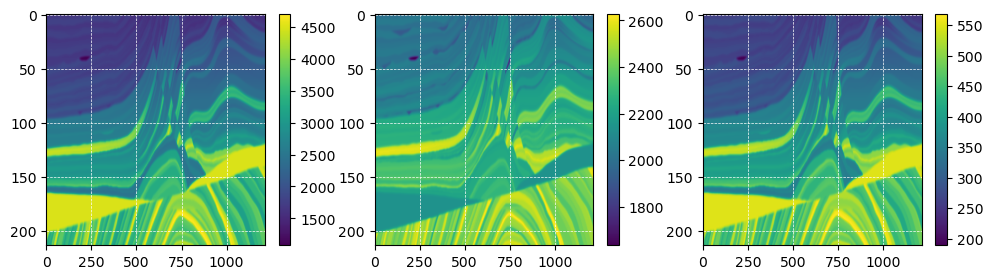

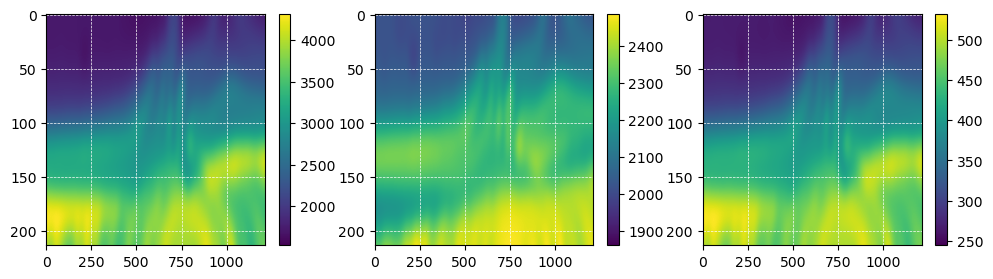

In [68]:
#plot

plt.figure(figsize=(12,3))

true=read('true',(3*nx,nz))
plt.subplot(1,3,1); imshow(true[:,:nx])
plt.subplot(1,3,2); imshow(true[:,nx:2*nx])
plt.subplot(1,3,3); imshow(true[:,2*nx:])

plt.figure(figsize=(12,3))

init=read('init',(3*nx,nz))
plt.subplot(1,3,1); imshow(init[:,:nx])
plt.subplot(1,3,2); imshow(init[:,nx:2*nx])
plt.subplot(1,3,3); imshow(init[:,2*nx:])

In [69]:
#min max of true vp
print(true[:,:nx].min(),true[:,:nx].max())

1078.463 4699.3086


## Observed data

In [70]:
!cp setup_default setup
!echo "DIR_OUT            results_obs_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
run()

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 21 Sep 23 08:28 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 1cc106b
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 09:06:13
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_noQ
 Output directory:results_obs_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
  

In [71]:
!cp setup_default setup
!echo "DIR_OUT          results_obs " >> setup
!echo "NS               1 " >> setup  #Number of Shots
#!echo "SNAPSHOT         p" >> setup
run()

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 21 Sep 23 08:28 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 1cc106b
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 09:06:47
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤

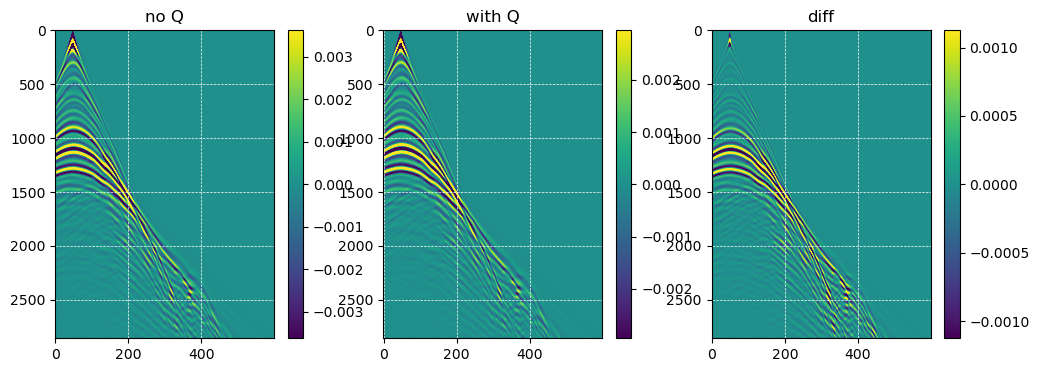

In [74]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs_noQ/Ru_Shot0001.su'),perc=98,title='no Q')
plt.subplot(1,3,2); imshow(read_su('results_obs/Ru_Shot0001.su'    ),perc=98,title='with Q')
plt.subplot(1,3,3); imshow(read_su('results_obs_noQ/Ru_Shot0001.su')-read_su('results_obs/Ru_Shot0001.su'),perc=98,title='diff')

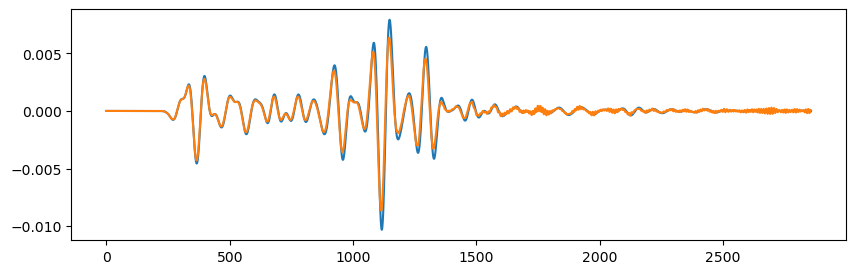

In [73]:
plt.figure(figsize=(10,3))
plt.plot(read_su('results_obs_noQ/Ru_Shot0001.su')[:,75])
plt.plot(read_su('results_obs/Ru_Shot0001.su'    )[:,75])

## FWI gradient

In [76]:
!cp setup_default setup
!echo "DIR_OUT            results_grad_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
run(app='../../exe/FWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 51 Sep 23 09:10 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 1cc106b
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 09:11:40
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad_noQ
 Output directory:results_grad_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef|

 ----  Computing obj func & dadj  ----
 WEIGHTING (WEI) : none
 WEIGHTING_OPERATIONS (WEI_OP) is NOT found, take default: multiply
 SU data write success.
 DATA_NORM (DNORM) is NOT found, take default: L2
 SU data write success.
 SU data write success.
 ----  Solving adjoint eqn & xcorrelate  ----
 it----        2500
 fld_reA minmax values:  -110334.711       79364.5703    
 fld_imA minmax values:  -123079.219       47648.6055    
 fld_reU minmax values:  -18.8203468       22.1759033    
 fld_imU minmax values:  -14.5748596       18.0155907    
 it----        2000
 fld_reA minmax values:  -367230.094       241743.719    
 fld_imA minmax values:  -316123.156       227173.453    
 fld_reU minmax values:  -28.8199501       55.0744247    
 fld_imU minmax values:  -50.8320351       33.3710976    
 it----        1500
 fld_reA minmax values:  -389072.438       312338.906    
 fld_imA minmax values:  -336456.031       305764.562    
 fld_reU minmax values:  -46.3463478       60.9758682    
 fl

In [77]:
!cp setup_default setup
!echo "DIR_OUT          results_grad " >> setup
!echo "NS               1 " >> setup  #Number of Shots
run(app='../../exe/FWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/11_Marmousi-runFWI
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 51 Sep 23 09:10 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 1cc106b
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/23/2025
System time: 09:12:44
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad
 Output directory:results_grad/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *

 ----  Computing obj func & dadj  ----
 WEIGHTING (WEI) : none
 WEIGHTING_OPERATIONS (WEI_OP) is NOT found, take default: multiply
 SU data write success.
 DATA_NORM (DNORM) is NOT found, take default: L2
 SU data write success.
 SU data write success.
 ----  Solving adjoint eqn & xcorrelate  ----
 it----        2500
 fld_reA minmax values:  -79552.4062       70266.3750    
 fld_imA minmax values:  -97084.8906       39869.8281    
 fld_reU minmax values:  -13.8209038       16.0558186    
 fld_imU minmax values:  -9.46957779       13.5178185    
 it----        2000
 fld_reA minmax values:  -286359.031       218066.109    
 fld_imA minmax values:  -245115.625       172416.000    
 fld_reU minmax values:  -23.0485134       41.9220200    
 fld_imU minmax values:  -38.6425171       27.4065456    
 it----        1500
 fld_reA minmax values:  -310333.562       256402.703    
 fld_imA minmax values:  -290433.312       235762.766    
 fld_reU minmax values:  -36.9586563       49.5867653    
 fl

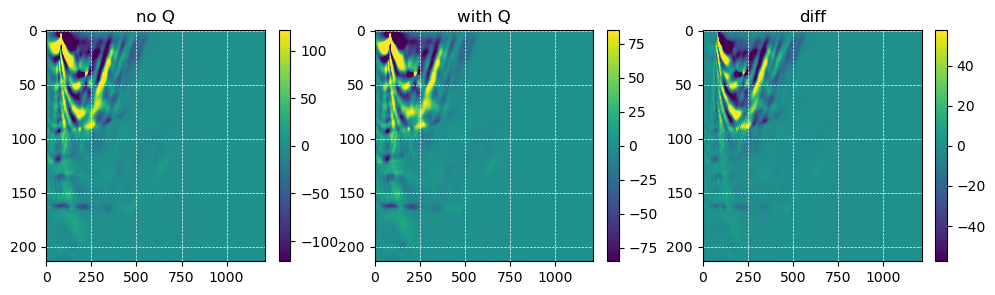

In [79]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results_grad_noQ/qp0%pg'),perc=98,title='no Q')
plt.subplot(1,3,2); imshow(read('results_grad/qp0%pg'    ),perc=98,title='with Q')
plt.subplot(1,3,3); imshow(read('results_grad_noQ/qp0%pg')-read('results_grad/qp0%pg'),perc=98,title='diff')

## FWI iterations

In [80]:
# ishot=1
#ishot=1:10:80
#ishot=1:20:144
ishot="'1:1:30'"



!cp setup_default setup
!echo "DIR_OUT            results " >> setup
!echo "ISHOT              $ishot " >> setup
!echo "SMOOTHING          Laplacian  "   >> setup
!echo "JOB                optimization " >> setup
#run(app='../../exe/FWI')